LOADING THE DATASET

In [ ]:
import pandas as pd
df1=pd.read_csv('/content/drive/MyDrive/clean_amazon_electronics.csv')
df2=pd.read_csv('/content/drive/MyDrive/cleaned_electronics_part0.csv')
df3=pd.read_csv('/content/drive/MyDrive/cleaned_electronics_part1.csv')
df4=pd.read_csv('/content/drive/MyDrive/cleaned_electronics_small.csv')


swapping the columns

In [ ]:
cols = list(df1.columns)

i, j = cols.index('review'), cols.index('rating')
cols[i], cols[j] = cols[j], cols[i]
df1 = df1[cols]


In [ ]:
cols = list(df4.columns)

i, j = cols.index('review'), cols.index('rating')
cols[i], cols[j] = cols[j], cols[i]
df4 = df4[cols]


merging the datset

In [ ]:
final_merge_df = pd.concat([df1, df2,df3,df4], ignore_index=True)

saving the dataset

In [ ]:
final_merge_df.to_csv('final_merge_df.csv', index=False)

In [ ]:
final_merge_df.shape

(14203931, 2)

rating count

In [ ]:
final_merge_df['rating'].value_counts()

,count
rating,
5,8463263
4,2495022
1,1337762
3,1145573
2,762311


In [2]:
import pandas as pd
final_merge_df = pd.read_csv(r'C:\Users\prave\Downloads\FINAL_PROJECT\final_merge_df.csv')

In [2]:
final_merge_df.shape

(14203931, 2)

In [3]:
final_merge_df.columns

Index(['review', 'rating'], dtype='object')

In [5]:
final_merge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14203931 entries, 0 to 14203930
Data columns (total 2 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   review  object
 1   rating  int64 
dtypes: int64(1), object(1)
memory usage: 216.7+ MB


Rating distribution

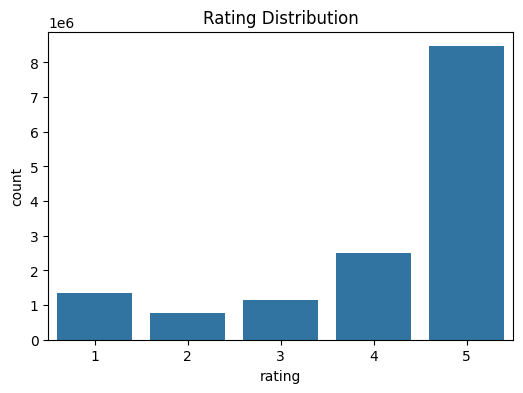

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='rating', data=final_merge_df)
plt.title("Rating Distribution")
plt.show()


In [ ]:
final_merge_df.head(5)

,review,rating
0,i was very surprised at the high quality of th...,5
1,i am a google employee and had to chance to us...,5
2,bought cables in ft ft and ft none of them wor...,1
3,nope cheap and slow,1
4,excellent great value and does the job,5


Review length distribution

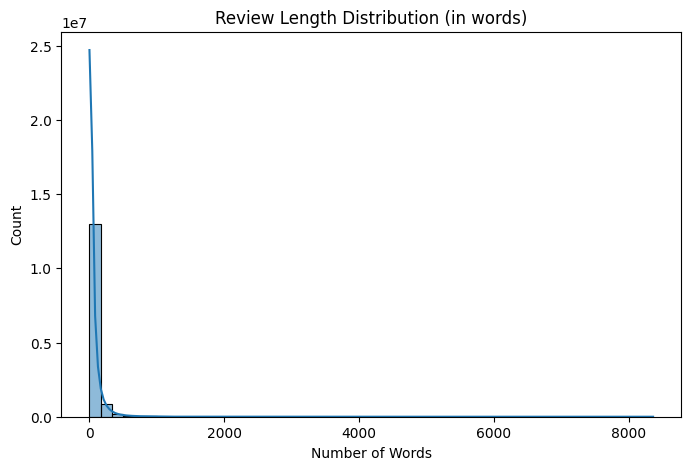

In [ ]:
final_merge_df['review_length'] = final_merge_df['review'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
sns.histplot(final_merge_df['review_length'], bins=50, kde=True)
plt.title("Review Length Distribution (in words)")
plt.xlabel("Number of Words")
plt.show()


rating distribution

/tmp/ipython-input-3739126681.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=final_merge_df, palette="viridis")


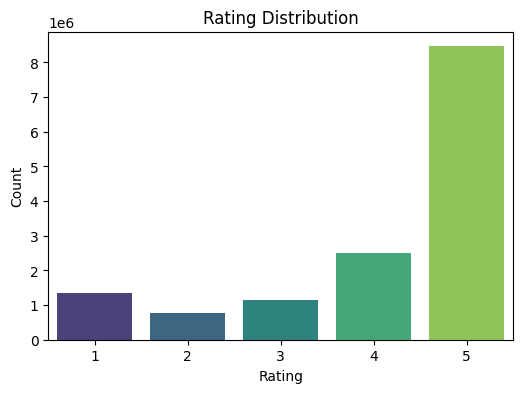

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='rating', data=final_merge_df, palette="viridis")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


Review length vs. rating

/tmp/ipython-input-2756123982.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rating', y='review_length', data=df, palette="coolwarm")


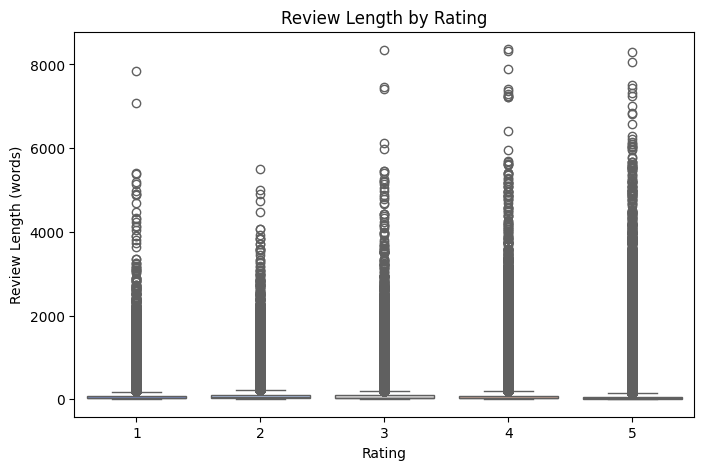

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df['review_length'] = df['review'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
sns.boxplot(x='rating', y='review_length', data=df, palette="coolwarm")
plt.title("Review Length by Rating")
plt.xlabel("Rating")
plt.ylabel("Review Length (words)")
plt.show()

Pie chart

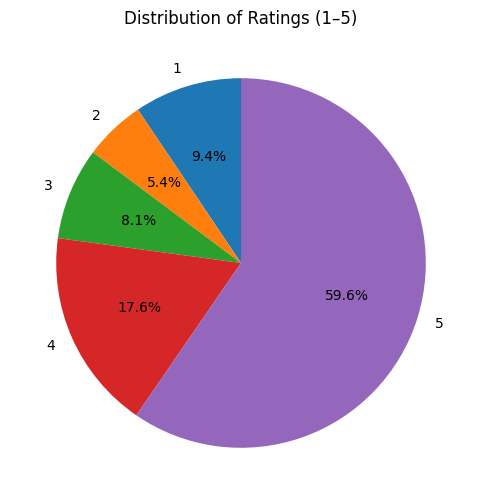

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

rating_counts = df['rating'].value_counts().sort_index()

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Distribution of Ratings (1–5)")
plt.show()


frequency

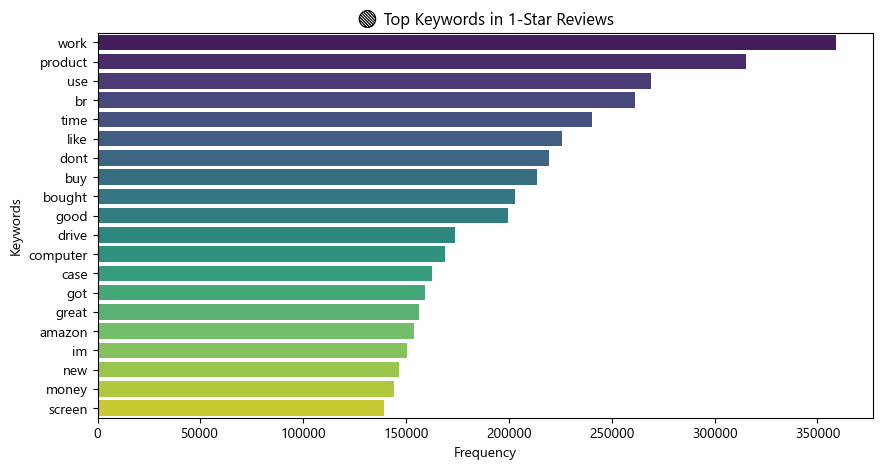

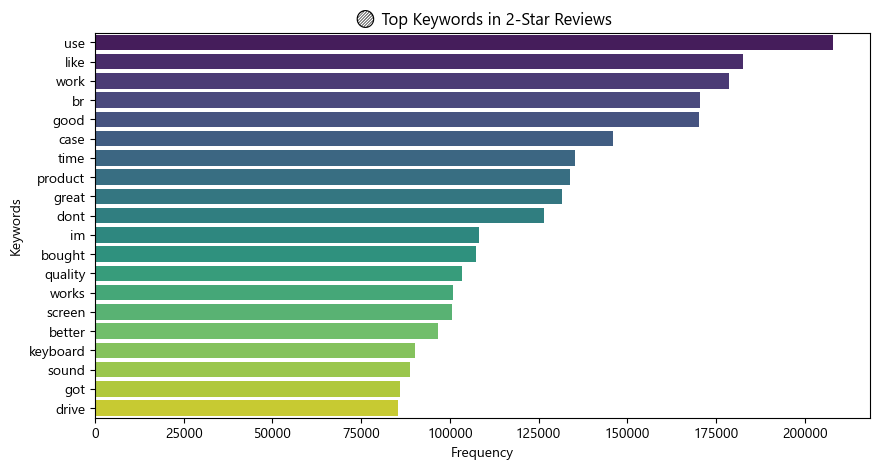

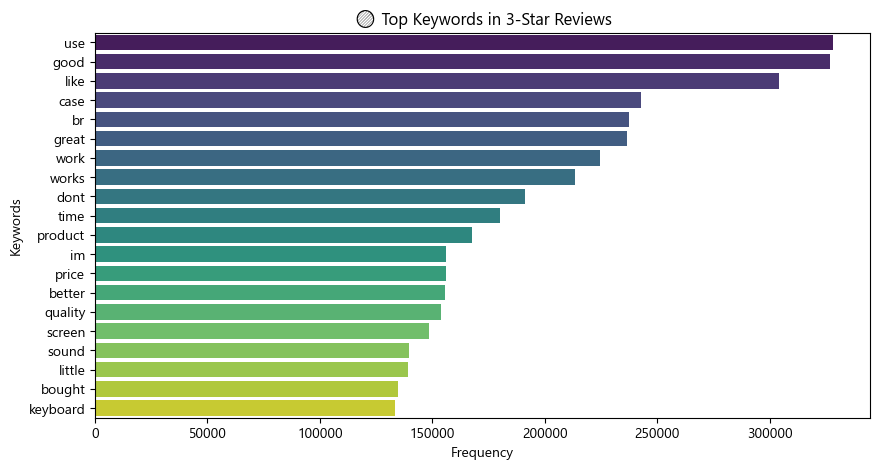

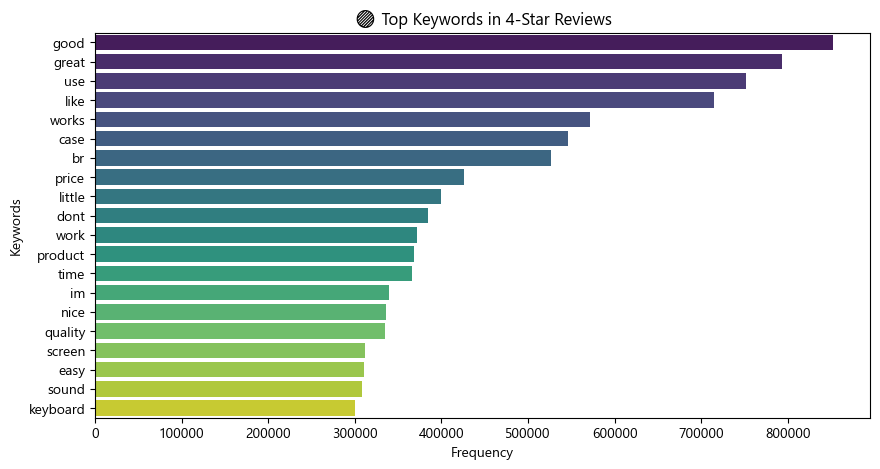

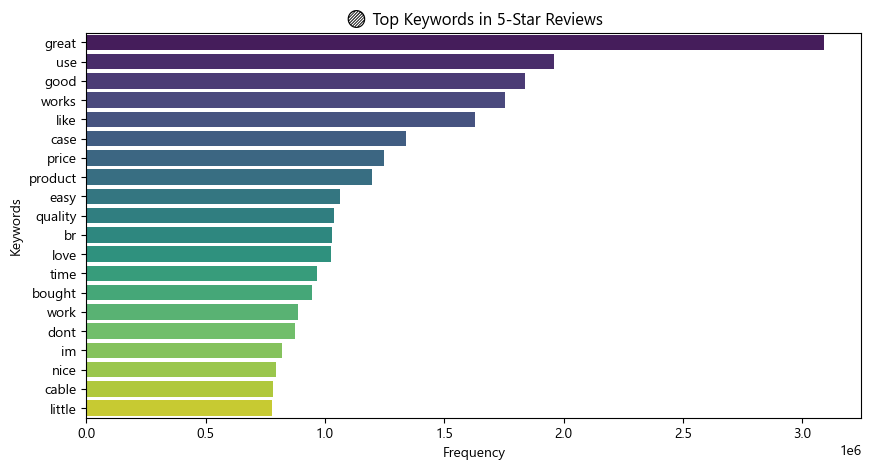

In [8]:
import spacy
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
final_merge_df['review']=final_merge_df['review'].astype(str)
final_merge_df['rating']=final_merge_df['rating'].astype(int)

# Use a font that supports emojis (Windows: Segoe UI Emoji)
plt.rcParams['font.family'] = 'Segoe UI Emoji'

# Load English model
nlp = spacy.load("en_core_web_sm")

def get_top_keywords(text_series, top_n=20):
    stop_words = spacy.lang.en.stop_words.STOP_WORDS
    words = " ".join(text_series).lower().split()
    words = [w for w in words if w.isalpha() and w not in stop_words]
    return Counter(words).most_common(top_n)

# Extract top keywords for each star rating
top_1_star = get_top_keywords(final_merge_df[final_merge_df['rating'] == 1]['review'])
top_2_star = get_top_keywords(final_merge_df[final_merge_df['rating'] == 2]['review'])
top_3_star = get_top_keywords(final_merge_df[final_merge_df['rating'] == 3]['review'])
top_4_star = get_top_keywords(final_merge_df[final_merge_df['rating'] == 4]['review'])
top_5_star = get_top_keywords(final_merge_df[final_merge_df['rating'] == 5]['review'])

# Plotting function
def plot_keywords(freq_list, title):
    words, counts = zip(*freq_list)
    plt.figure(figsize=(10, 5))
    sns.barplot(
        x=list(counts),
        y=list(words),
        hue=list(words),       # assign y to hue
        palette="viridis",
        legend=False           # hide redundant legend
    )
    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel("Keywords")
    plt.show()

# Generate plots
plot_keywords(top_1_star, "🔴 Top Keywords in 1-Star Reviews")
plot_keywords(top_2_star, "🟠 Top Keywords in 2-Star Reviews")
plot_keywords(top_3_star, "🟡 Top Keywords in 3-Star Reviews")
plot_keywords(top_4_star, "🟣 Top Keywords in 4-Star Reviews")
plot_keywords(top_5_star, "🟢 Top Keywords in 5-Star Reviews")


Review Density Heatmap

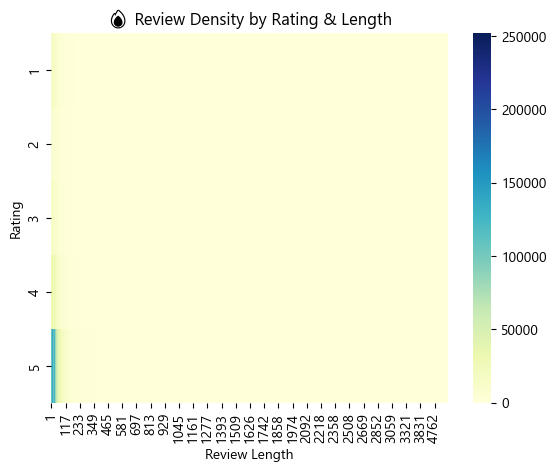

In [10]:
final_merge_df['length'] = final_merge_df['review'].apply(lambda x: len(str(x).split()))
heatmap_data = final_merge_df.pivot_table(index='rating', columns='length', aggfunc='size', fill_value=0)

sns.heatmap(heatmap_data, cmap='YlGnBu')
plt.title("🔥 Review Density by Rating & Length")
plt.xlabel("Review Length")
plt.ylabel("Rating")
plt.show()

In [ ]:
import textstat

final_merge_df['readability'] = final_merge_df['review'].apply(lambda x: textstat.flesch_reading_ease(str(x)))

sns.boxplot(data=final_merge_df, x='rating', y='readability', palette='mako')
plt.title("📚 Review Readability vs. Rating")
plt.xlabel("Rating")
plt.ylabel("Flesch Reading Ease Score")
plt.show()

HORIZONTAL BAR CHART

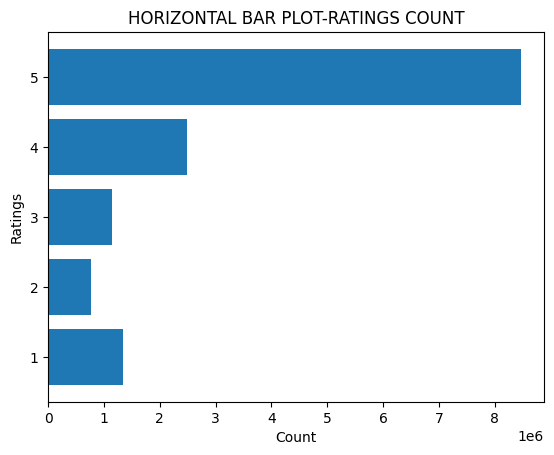

In [4]:
import matplotlib.pyplot as plt
x=final_merge_df['rating'].value_counts().index
y=final_merge_df['rating'].value_counts().values
plt.barh(x,y)
plt.title("HORIZONTAL BAR PLOT-RATINGS COUNT")
plt.xlabel("Count")
plt.ylabel("Ratings")
plt.show()

In [ ]:
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/final_merge_df.csv')

FINAL DATASET

In [3]:
import pandas as pd

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Desired sample sizes based on % targets
target_counts = {
    1: 480000,
    2: 300000,
    3: 420000,
    4: 470000,
    5: 500000
}

# Apply sampling
sampled = []

for rating, count in target_counts.items():
    group = df[df['rating'] == rating]
    if len(group) >= count:
        sampled.append(group.sample(n=count, random_state=42)) # Use sample(n=count)
    else:
        sampled.append(group) # If group is smaller than count, take all

final_df = pd.concat(sampled).reset_index(drop=True)

# Check result
print(final_df['rating'].value_counts(normalize=True) * 100)  # % distribution

rating
5    23.041475
1    22.119816
4    21.658986
3    19.354839
2    13.824885
Name: proportion, dtype: float64


PIE CHART

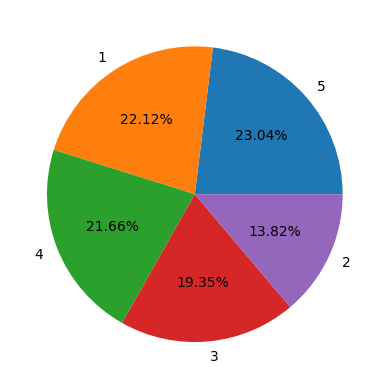

In [4]:
import matplotlib.pyplot as plt
plt.pie(final_df['rating'].value_counts(),labels=final_df['rating'].value_counts().index,autopct='%1.2f%%')
plt.show()

In [ ]:
final_df.to_csv('final_dl_df.csv',index=False)

In [5]:
import pandas as pd 
df=pd.read_csv(r'C:\Users\prave\Downloads\FINAL_PROJECT\final_dl_df.csv')

COMMON WORDS

C:\Users\prave\AppData\Local\Temp\ipykernel_11488\3410775527.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="count", y="word", data=wc_df, palette="viridis")


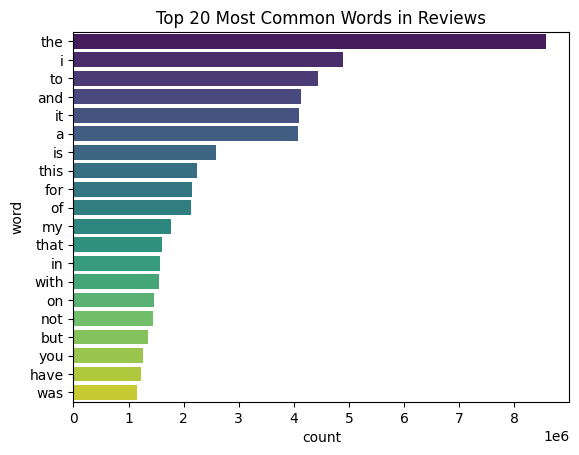

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
from collections import Counter



# Clean and join all reviews
all_text = " ".join(df["review"].fillna("").astype(str).str.lower())


# Tokenize into words
words = all_text.split()

# Count frequency
word_freq = Counter(words)

# Get top 20 words
most_common_words = word_freq.most_common(20)

# Convert to DataFrame for plotting
wc_df = pd.DataFrame(most_common_words, columns=["word", "count"])

sns.barplot(x="count", y="word", data=wc_df, palette="viridis")
plt.title("Top 20 Most Common Words in Reviews")
plt.show()

HORIZONTAL BAR

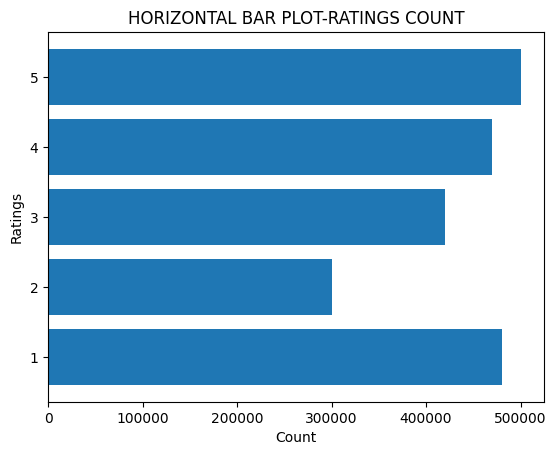

In [9]:
import matplotlib.pyplot as plt
x=df['rating'].value_counts().index
y=df['rating'].value_counts().values
plt.barh(x,y)
plt.title("HORIZONTAL BAR PLOT-RATINGS COUNT")
plt.xlabel("Count")
plt.ylabel("Ratings")
plt.show()

REVIEW LENGTH DISTRIBUTION

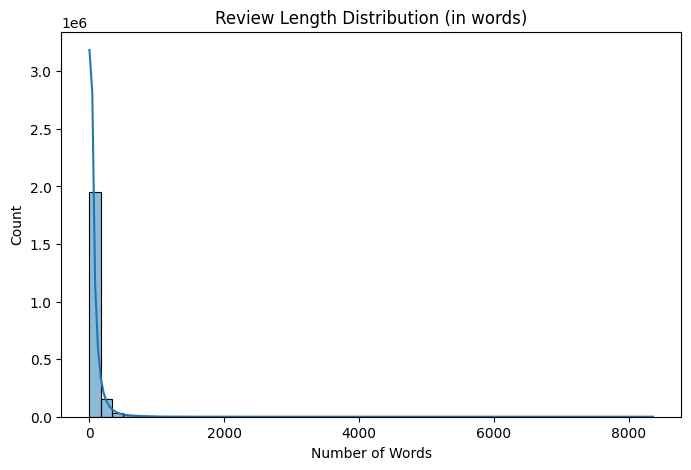

In [11]:
df['review_length'] = df['review'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
sns.histplot(df['review_length'], bins=50, kde=True)
plt.title("Review Length Distribution (in words)")
plt.xlabel("Number of Words")
plt.show()


REVIEW LENGTH BY RATING

C:\Users\prave\AppData\Local\Temp\ipykernel_11488\3201482357.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rating', y='review_length', data=df, palette="coolwarm")


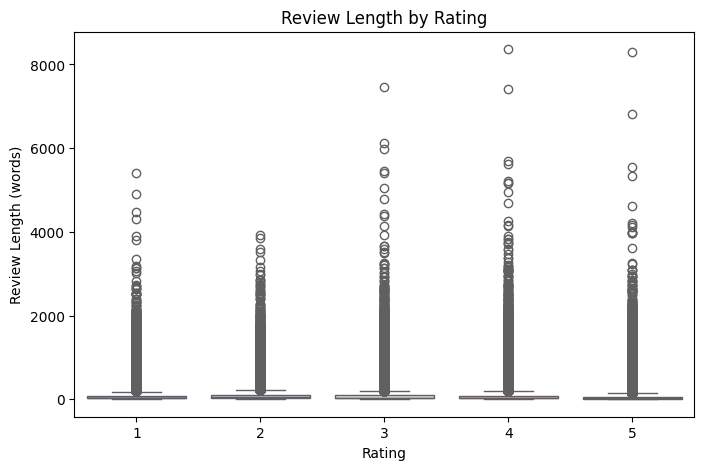

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

df['review_length'] = df['review'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
sns.boxplot(x='rating', y='review_length', data=df, palette="coolwarm")
plt.title("Review Length by Rating")
plt.xlabel("Rating")
plt.ylabel("Review Length (words)")
plt.show()

FREQUENCY

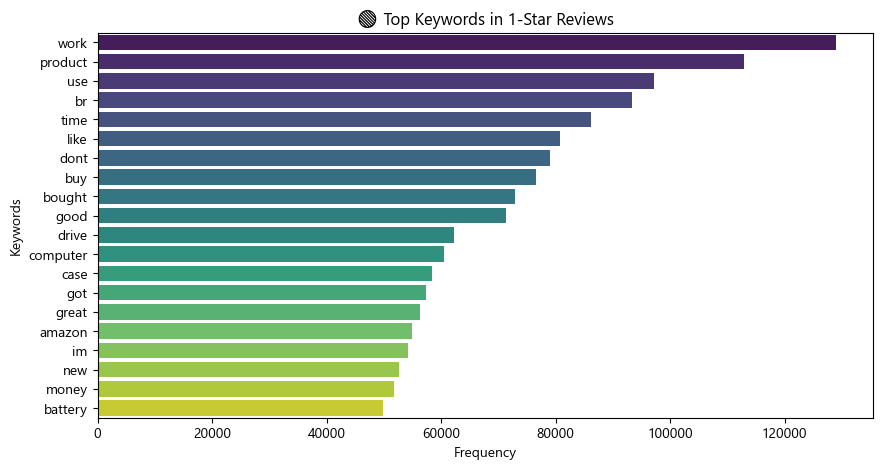

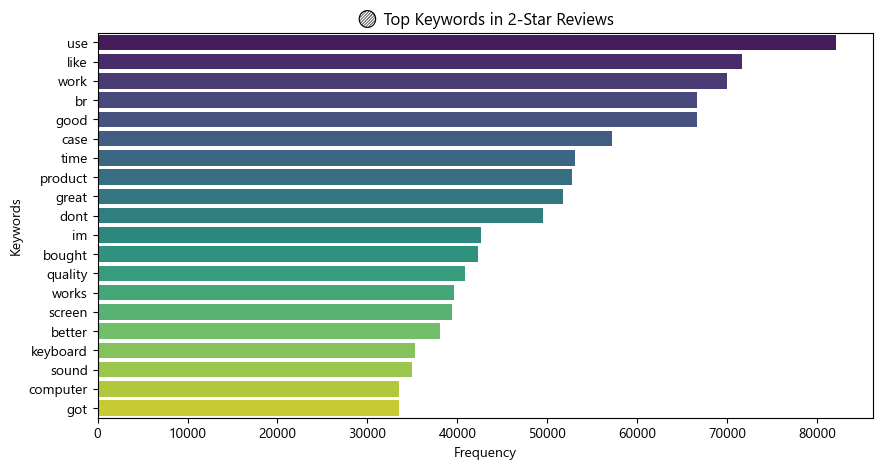

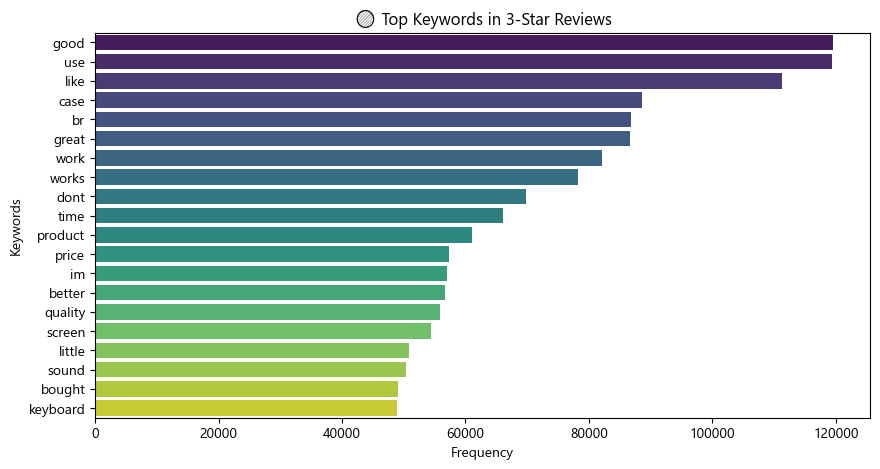

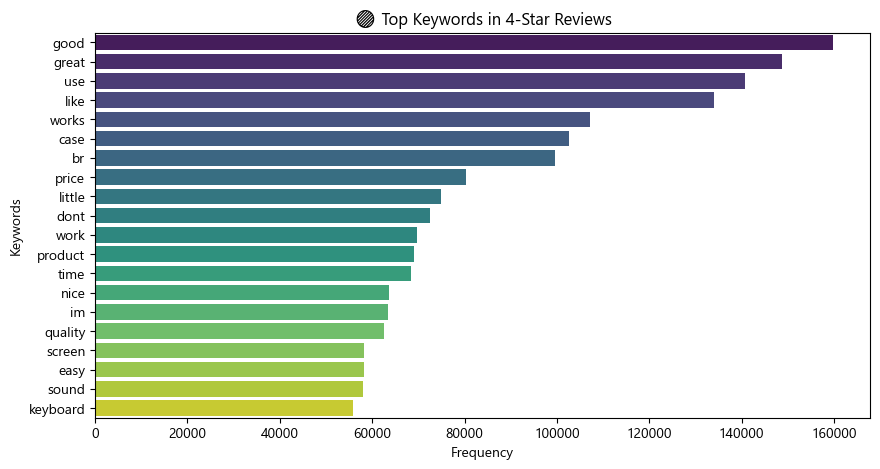

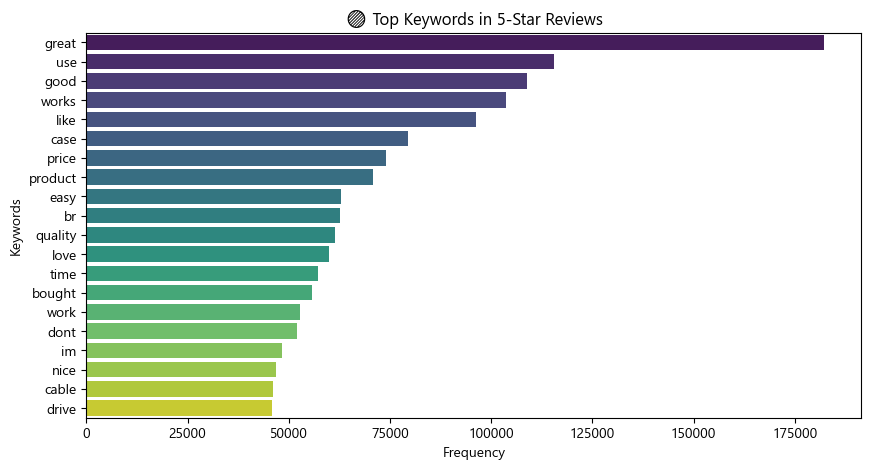

In [13]:
import spacy
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
df['review']=df['review'].astype(str)
df['rating']=df['rating'].astype(int)

# Use a font that supports emojis (Windows: Segoe UI Emoji)
plt.rcParams['font.family'] = 'Segoe UI Emoji'

# Load English model
nlp = spacy.load("en_core_web_sm")

def get_top_keywords(text_series, top_n=20):
    stop_words = spacy.lang.en.stop_words.STOP_WORDS
    words = " ".join(text_series).lower().split()
    words = [w for w in words if w.isalpha() and w not in stop_words]
    return Counter(words).most_common(top_n)

# Extract top keywords for each star rating
top_1_star = get_top_keywords(df[df['rating'] == 1]['review'])
top_2_star = get_top_keywords(df[df['rating'] == 2]['review'])
top_3_star = get_top_keywords(df[df['rating'] == 3]['review'])
top_4_star = get_top_keywords(df[df['rating'] == 4]['review'])
top_5_star = get_top_keywords(df[df['rating'] == 5]['review'])

# Plotting function
def plot_keywords(freq_list, title):
    words, counts = zip(*freq_list)
    plt.figure(figsize=(10, 5))
    sns.barplot(
        x=list(counts),
        y=list(words),
        hue=list(words),       # assign y to hue
        palette="viridis",
        legend=False           # hide redundant legend
    )
    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel("Keywords")
    plt.show()

# Generate plots
plot_keywords(top_1_star, "🔴 Top Keywords in 1-Star Reviews")
plot_keywords(top_2_star, "🟠 Top Keywords in 2-Star Reviews")
plot_keywords(top_3_star, "🟡 Top Keywords in 3-Star Reviews")
plot_keywords(top_4_star, "🟣 Top Keywords in 4-Star Reviews")
plot_keywords(top_5_star, "🟢 Top Keywords in 5-Star Reviews")


Review Density Heatmap

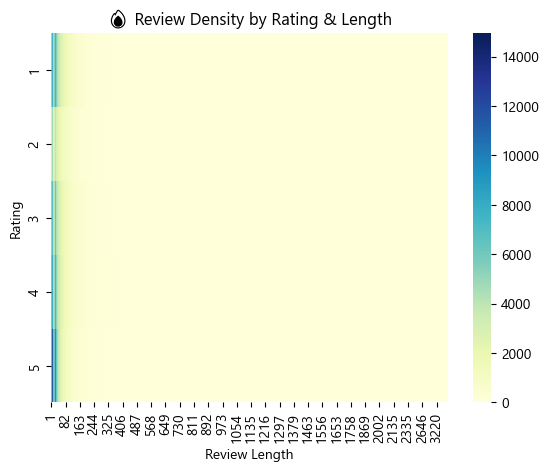

In [14]:
df['length'] = df['review'].apply(lambda x: len(str(x).split()))
heatmap_data = df.pivot_table(index='rating', columns='length', aggfunc='size', fill_value=0)

sns.heatmap(heatmap_data, cmap='YlGnBu')
plt.title("🔥 Review Density by Rating & Length")
plt.xlabel("Review Length")
plt.ylabel("Rating")
plt.show()